# Joint Photometry + Spectroscopy

**Spine:** [`08_fitting_spectra.py`](08_fitting_spectra.py) compares photometry vs spectroscopy;
this notebook adds the **three-way** posterior comparison (phot-only, spec-only, joint) on the
same mock. See also [`07_fitting_photometry.py`](07_fitting_photometry.py) for catalog fitting.

Broadband photometry constrains the overall SED shape -- stellar mass,
dust attenuation, and redshift -- but cannot break the age-dust-metallicity
degeneracy. Spectroscopy resolves individual absorption and emission
features that pin down stellar ages and chemical enrichment, yet covers
a limited wavelength range. Joint fitting exploits both: photometry
anchors the broadband continuum while spectroscopy supplies the fine
detail, yielding tighter posteriors than either dataset alone.

This notebook demonstrates the `Observation` class for joint fitting
in tengri: constructing a joint observation, generating mock data,
running MAP inference, and comparing constraints from photometry-only,
spectroscopy-only, and joint fits.

In [1]:
import os
import sys
import time
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import importlib.util

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

from tengri import (
    Fitter,
    Fixed,
    SEDModel,
    Observation,
    Parameters,
    Photometry,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures", "14_joint")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

W0423 01:13:37.578970 22988602 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


### Aperture mismatch

When combining photometry and spectroscopy from different instruments, a common
pitfall is **aperture mismatch**: photometric apertures (e.g., 3″ Kron) typically
capture more flux than spectroscopic slits (e.g., 1″ fiber). This creates a
flux normalization offset between the two data types.

**Solutions:**
1. Measure photometry within the spectroscopic aperture (requires imaging)
2. Fit a free flux-calibration polynomial (use `marginalize_calibration`)
3. Increase photometric error bars to absorb the mismatch

This notebook uses synthetic data with matched apertures. For real data,
approach 2 is recommended — see `observation/calibration.py`.

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

## Creating a Joint Observation

The `Observation` class bundles photometry and spectroscopy into a single
declarative object. Pass `Photometry` for broadband filters and
`Spectroscopy` for the wavelength grid and instrument settings.
The model will produce predictions for both in a single forward pass.

In [3]:
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)

obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS, resolution=100),
)

print(obs.summary())
print(f"\nis_joint: {obs.is_joint}")
print(f"n_data:   {obs.n_data}  ({obs.n_data_phot} phot + {obs.n_data_spec} spec)")

Observation
--------------------------------------------------
  Photometry : 5 filters: sdss_u, sdss_g, sdss_r, sdss_i, sdss_z
  Spectroscopy : 200 pixels, R=100
  Data type  : joint
  N data     : 205
               (5 phot + 200 spec)

is_joint: True
n_data:   205  (5 phot + 200 spec)


## Generate Joint Mock Data

We create a `Model` with the joint observation and generate mock
photometry and spectroscopy from a known truth. The same forward model
parameters produce both data vectors simultaneously.

In [4]:
spec = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)

model = SEDModel(spec, ssp_data, observation=obs)

key = jax.random.PRNGKey(42)
true_params = spec.sample(key)
# Override to a typical star-forming galaxy
true_params = {
    **true_params,
    "sfh_tsnorm_log_peak_sfr": jnp.array(1.2),
    "sfh_tsnorm_peak_lbt_gyr": jnp.array(3.0),
    "sfh_tsnorm_width_gyr": jnp.array(3.0),
    "sfh_tsnorm_skew": jnp.array(0.3),
    "sfh_tsnorm_trunc": jnp.array(2.0),
}

# Generate mock photometry and spectrum separately, then pack
k1, k2 = jax.random.split(key)
mock_phot = model.mock(true_params, snr=20.0, key=k1)
mock_spec = model.mock_spectrum(true_params, WAVE_OBS, snr=30.0, key=k2)

# Pack into joint data vector using Observation
data_joint = obs.pack_data(phot=mock_phot.flux_obs, spec=mock_spec.flux_obs)
noise_joint = obs.pack_data(phot=mock_phot.noise, spec=mock_spec.noise)

print(f"Joint data vector shape: {data_joint.shape}")

/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:517: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()


Joint data vector shape: (205,)


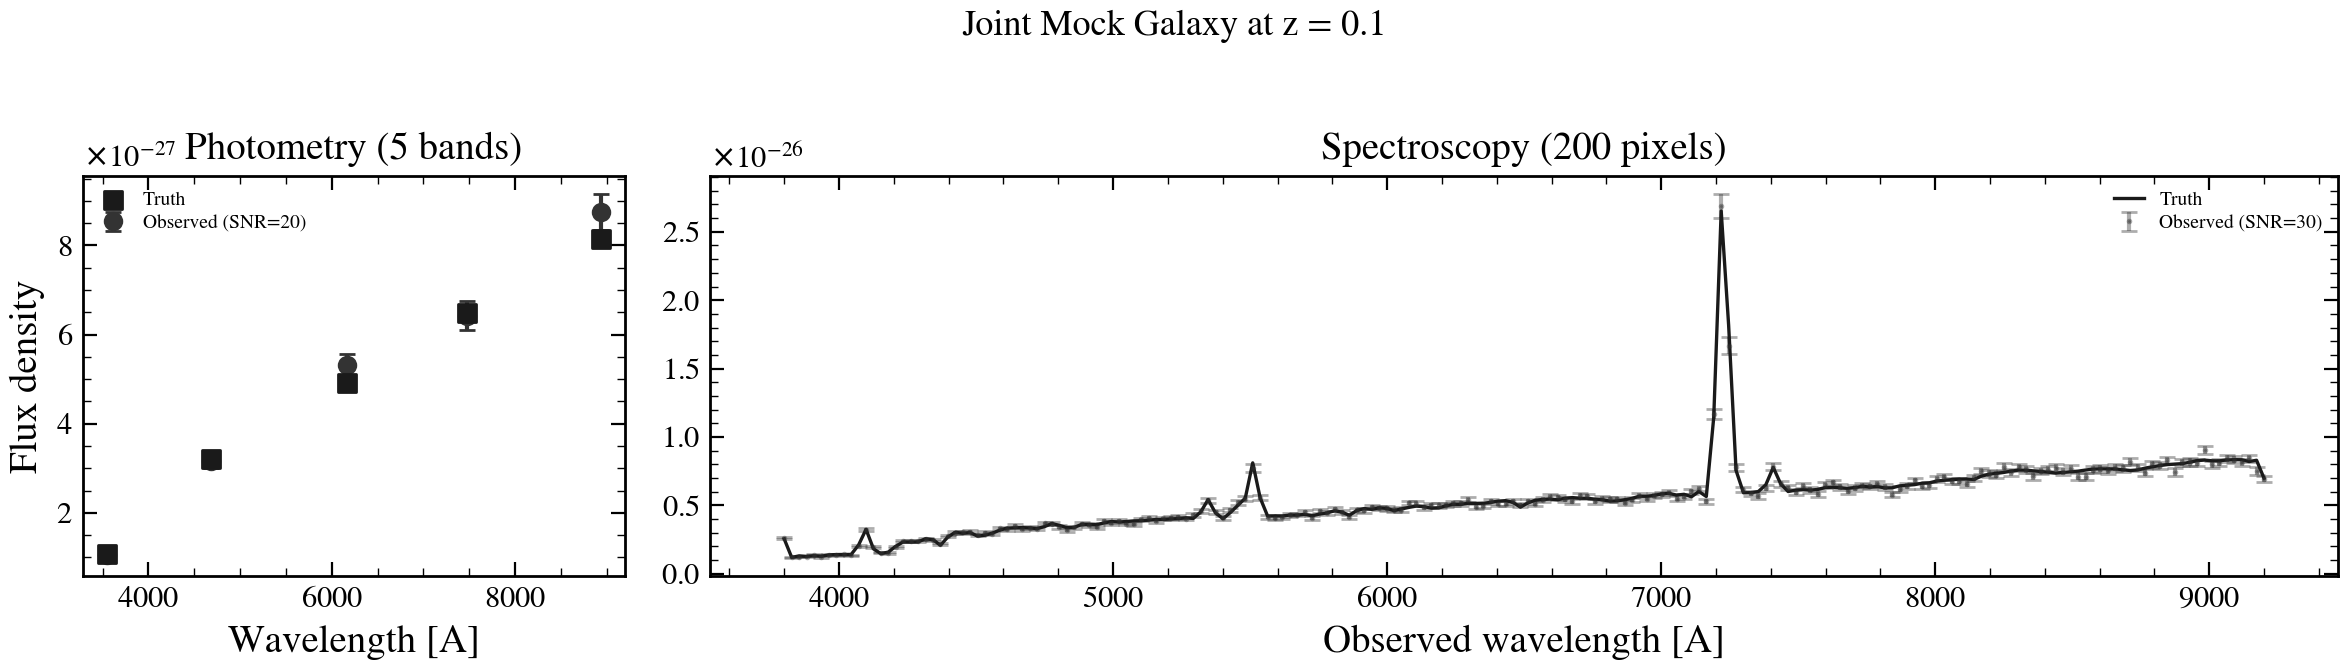

In [5]:
# --- FIGURE 1: Two-panel mock data ---
fig, (ax_p, ax_s) = plt.subplots(1, 2, figsize=(12, 3.5), gridspec_kw={"width_ratios": [1, 3]})

# Photometry panel
wave_eff = np.array([3551, 4686, 6166, 7480, 8932])  # SDSS effective wavelengths
ax_p.errorbar(
    wave_eff,
    np.array(mock_phot.flux_obs),
    yerr=np.array(mock_phot.noise),
    fmt="o",
    ms=6,
    color=COLORS["data"],
    label="Observed (SNR=20)",
)
ax_p.scatter(
    wave_eff,
    np.array(mock_phot.flux_true),
    marker="s",
    s=40,
    color=COLORS["truth"],
    zorder=5,
    label="Truth",
)
ax_p.set_xlabel("Wavelength [A]")
ax_p.set_ylabel("Flux density")
ax_p.set_title("Photometry (5 bands)")
ax_p.legend(fontsize=7)

# Spectrum panel
w = np.array(WAVE_OBS)
ax_s.errorbar(
    w,
    np.array(mock_spec.flux_obs),
    yerr=np.array(mock_spec.noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.4,
    label="Observed (SNR=30)",
)
ax_s.plot(w, np.array(mock_spec.flux_true), color=COLORS["truth"], lw=1.2, label="Truth")
ax_s.set_xlabel("Observed wavelength [A]")
ax_s.set_title("Spectroscopy (200 pixels)")
ax_s.legend(fontsize=7)

fig.suptitle("Joint Mock Galaxy at z = 0.1", fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig11_joint_mock_data.png"), dpi=150, bbox_inches="tight")
plt.show()

## Fit with MAP

The `Fitter` accepts the packed joint data vector. Because the `Model`
carries the `Observation`, the fitter automatically infers
`data_type="joint"` and dispatches the correct likelihood.

In [6]:
fitter = Fitter(model, data_joint, noise_joint)
print(f"Fitter data_type: {fitter.data_type}")

t0 = time.perf_counter()
result_map = fitter.run("map", n_steps=500, verbose=False)
t_fit = time.perf_counter() - t0
print(f"MAP fit completed in {t_fit:.1f}s")

Fitter data_type: joint


MAP fit completed in 6.0s


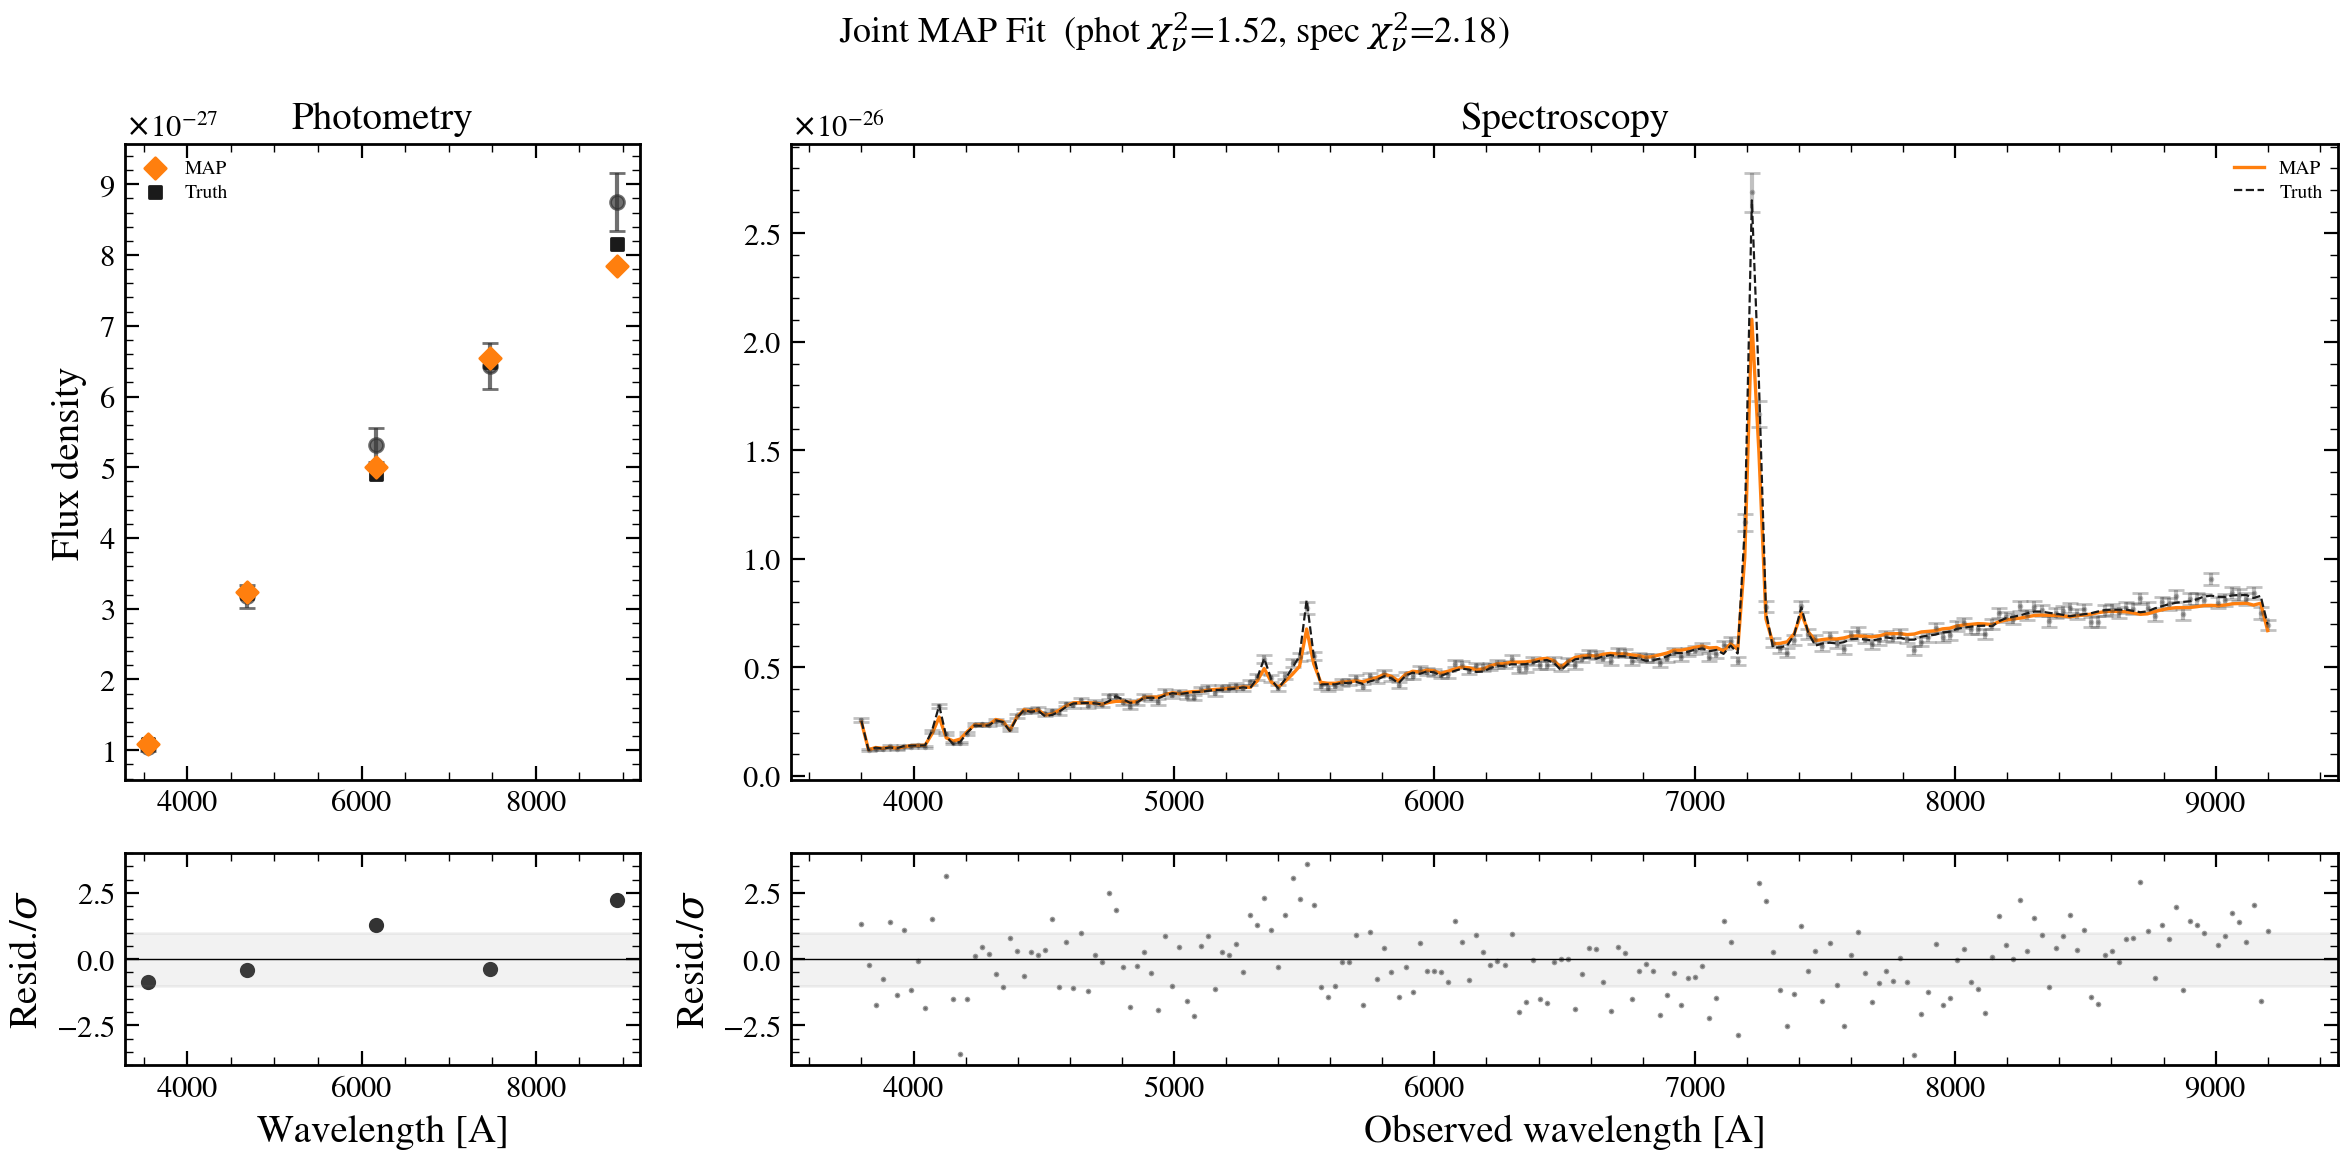

In [7]:
# --- FIGURE 2: Joint fit quality (photometry + spectrum + residuals) ---
map_params = result_map.best_fit if hasattr(result_map, "best_fit") else result_map.params

pred_phot = np.array(model.predict_photometry(map_params))
pred_spec = np.array(model.predict_spectrum(map_params))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 6),
    gridspec_kw={"height_ratios": [3, 1], "width_ratios": [1, 3]},
)
ax_p, ax_s = axes[0]
ax_pr, ax_sr = axes[1]

# Photometry fit
ax_p.errorbar(
    wave_eff,
    np.array(mock_phot.flux_obs),
    yerr=np.array(mock_phot.noise),
    fmt="o",
    ms=5,
    color=COLORS["data"],
    alpha=0.7,
)
ax_p.scatter(wave_eff, pred_phot, marker="D", s=30, color=COLORS["vi"], zorder=5, label="MAP")
ax_p.scatter(
    wave_eff,
    np.array(mock_phot.flux_true),
    marker="s",
    s=20,
    color=COLORS["truth"],
    zorder=4,
    label="Truth",
)
ax_p.set_ylabel("Flux density")
ax_p.set_title("Photometry")
ax_p.legend(fontsize=7)

# Photometry residuals
res_p = (np.array(mock_phot.flux_obs) - pred_phot) / np.array(mock_phot.noise)
ax_pr.scatter(wave_eff, res_p, s=20, c=COLORS["data"])
ax_pr.axhline(0, color="k", lw=0.5)
ax_pr.axhspan(-1, 1, alpha=0.1, color="grey")
ax_pr.set_ylim(-4, 4)
ax_pr.set_xlabel("Wavelength [A]")
ax_pr.set_ylabel(r"Resid./$\sigma$")

# Spectrum fit
ax_s.errorbar(
    w,
    np.array(mock_spec.flux_obs),
    yerr=np.array(mock_spec.noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.3,
)
ax_s.plot(w, pred_spec, color=COLORS["vi"], lw=1.2, label="MAP")
ax_s.plot(w, np.array(mock_spec.flux_true), color=COLORS["truth"], lw=0.8, ls="--", label="Truth")
ax_s.set_title("Spectroscopy")
ax_s.legend(fontsize=7)

# Spectrum residuals
res_s = (np.array(mock_spec.flux_obs) - pred_spec) / np.array(mock_spec.noise)
ax_sr.scatter(w, res_s, s=1, c=COLORS["data"], alpha=0.5)
ax_sr.axhline(0, color="k", lw=0.5)
ax_sr.axhspan(-1, 1, alpha=0.1, color="grey")
ax_sr.set_ylim(-4, 4)
ax_sr.set_xlabel("Observed wavelength [A]")
ax_sr.set_ylabel(r"Resid./$\sigma$")

chi2_p = np.sum(res_p**2) / len(res_p)
chi2_s = np.sum(res_s**2) / len(res_s)
fig.suptitle(
    f"Joint MAP Fit  (phot $\\chi^2_\\nu$={chi2_p:.2f}, spec $\\chi^2_\\nu$={chi2_s:.2f})",
    fontsize=13,
)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig11_joint_map_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

## Comparing Constraints: Photometry vs Spectroscopy vs Joint

To see the advantage of joint fitting, we run three separate MAP fits
using the same model and truth but different data combinations. We
then compare the best-fit parameter errors.

In [8]:
# Photometry-only model and fit
obs_phot = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
)
model_phot = SEDModel(spec, ssp_data, observation=obs_phot)
fitter_phot = Fitter(model_phot, mock_phot.flux_obs, mock_phot.noise)
result_phot = fitter_phot.run("map", n_steps=500, verbose=False)

# Spectroscopy-only model and fit
obs_spec = Observation(
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS, resolution=100),
)
model_spec = SEDModel(spec, ssp_data, observation=obs_spec)
fitter_spec = Fitter(model_spec, mock_spec.flux_obs, mock_spec.noise)
result_spec = fitter_spec.run("map", n_steps=500, verbose=False)

W0423 01:13:52.005305 22988790 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0423 01:13:52.334922 22988679 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0423 01:13:56.094116 22988445 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


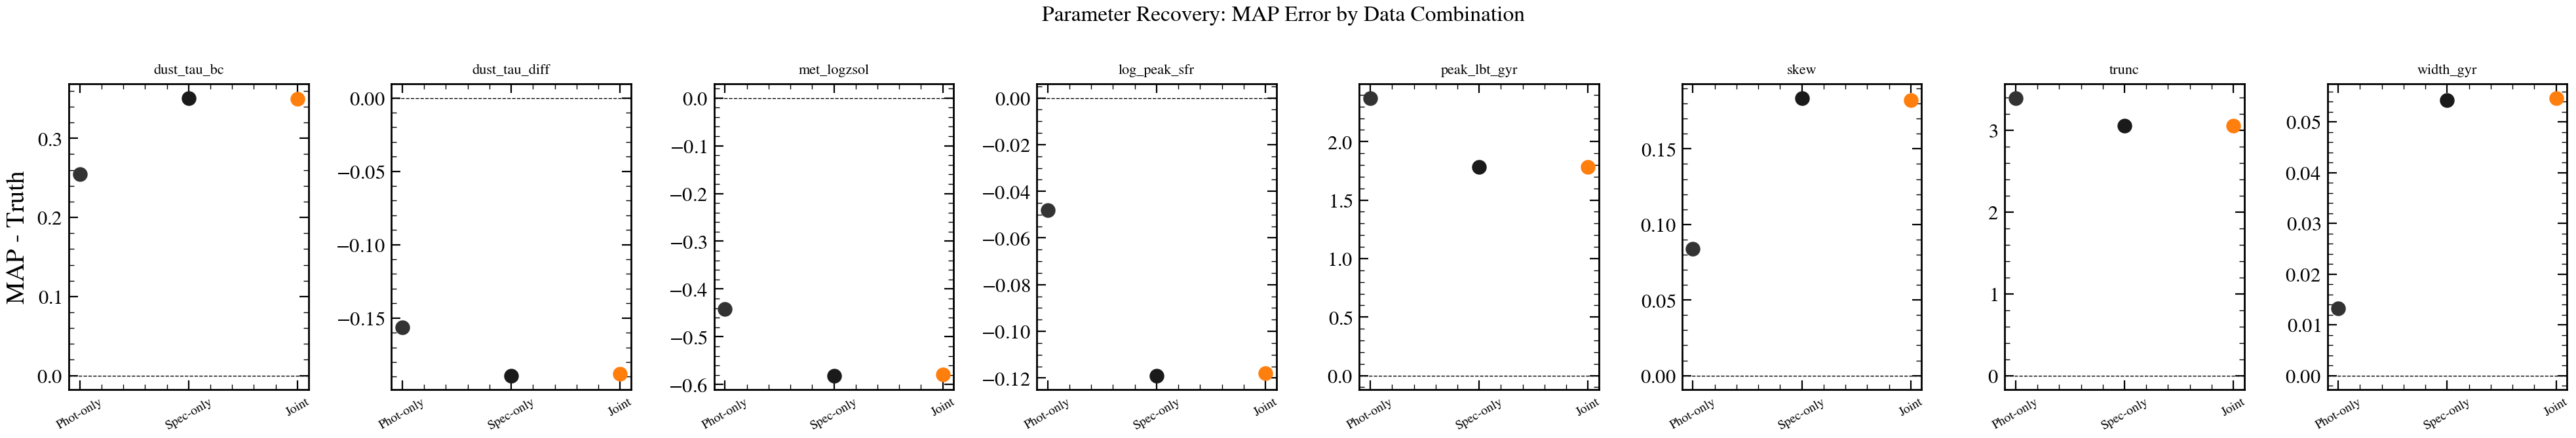

W0423 01:14:00.783213 22988837 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


In [9]:
# --- FIGURE 3: Parameter recovery comparison ---
results = {
    "Phot-only": result_phot,
    "Spec-only": result_spec,
    "Joint": result_map,
}

param_names = spec.free_params
true_vals = {p: float(true_params[p]) for p in param_names}

fig, axes = plt.subplots(1, len(param_names), figsize=(2.5 * len(param_names), 3.5))
colors_list = [COLORS.get("data", "C0"), COLORS.get("truth", "C1"), COLORS.get("vi", "C2")]

for i, pname in enumerate(param_names):
    ax = axes[i]
    tv = true_vals[pname]

    for j, (_label, res) in enumerate(results.items()):
        bf = res.best_fit if hasattr(res, "best_fit") else res.params
        val = float(bf[pname])
        ax.scatter(j, val - tv, s=50, color=colors_list[j], zorder=5)

    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels(list(results.keys()), fontsize=7, rotation=30)
    ax.set_title(pname.replace("sfh_tsnorm_", ""), fontsize=8)
    if i == 0:
        ax.set_ylabel("MAP - Truth")

fig.suptitle("Parameter Recovery: MAP Error by Data Combination", fontsize=12)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig11_constraint_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## Full Posterior Inference on Joint Data

MAP gives a single best-fit point but no uncertainty. Here we run geoVI
(variational inference via NIFTy.re) on the joint fitter, then repeat on
phot-only and spec-only observations to compare posterior widths.
`posterior_chunk_size=64` caps peak memory by drawing CG samples in chunks.

In [10]:
k_post = jax.random.PRNGKey(99)

t0 = time.perf_counter()
result_geovi = fitter.run(
    "vi",
    key=k_post,
    n_iterations=8,
    n_samples=4,
    n_posterior_samples=400,
    posterior_chunk_size=64,
    verbose=False,
)
t_geovi = time.perf_counter() - t0

print(f"vi (geoVI): {t_geovi:.1f}s")
# Laplace / Pathfinder comparison fits removed — they blow CPU memory on the
# joint spec+phot likelihood. See 08_fitting_spectra for a spec-only multi-method
# comparison; this notebook keeps the focus on phot-vs-spec-vs-joint posteriors.
result_laplace = None
result_pathfinder = None
t_laplace = 0.0
t_pathfinder = 0.0

# Drop the joint fitter's internal caches before compiling the phot-only and
# spec-only models (each compilation holds ~GB of XLA buffers otherwise).
import gc as _gc

del fitter
_gc.collect()

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)
OPTIMIZE_KL: Starting 0001


SL: Iteration 0 ⛰:+1.5250e+04 Δ⛰:inf ➽:1.0000e-04


SL: Iteration 0 ⛰:+7.0714e+04 Δ⛰:inf ➽:1.0000e-04


...

MCG: Iteration 6 ⛰:-6.1509e-04 Δ⛰:1.1264e-04 ➽:2.5464e-04 |∇|:5.0331e-01 ➽:6.9790e-01


M: →:1.0 ↺:False #∇²:24 |↘|:8.099131e-03 🞋:8.000000e-05
M: Iteration 4 ⛰:+6.782101e+02 Δ⛰:4.284057e-04 🞋:1.000000e-03


OPTIMIZE_KL: Iteration 0008 ⛰:+6.7821e+02
OPTIMIZE_KL: #(Nonlinear sampling steps) (3, 3, 3, 3, 3, 3, 3, 3)
OPTIMIZE_KL: #(KL minimization steps) 4
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     6.6±   0.048, avg:    +0.18±   0.089, #dof:    205'

OPTIMIZE_KL: Prior residual(s):
dust_tau_bc             :: 'reduced χ²:    0.13±   0.088, avg:    +0.33±    0.13, #dof:      1'
dust_tau_diff           :: 'reduced χ²:   0.024±   0.032, avg:   -0.079±    0.13, #dof:      1'
met_logzsol             :: 'reduced χ²:    0.19±   0.061, avg:    +0.43±   0.069, #dof:      1'
sfh_tsnorm_log_peak_sfr :: 'reduced χ²:    0.25±   0.079, avg:    +0.49±   0.077, #dof:      1'
sfh_tsnorm_peak_lbt_gyr :: 'reduced χ²:     1.7±    0.38, avg:     -1.3±    0.14, #dof:      1'
sfh_tsnorm_skew         :: 'reduced χ²:   0.023±   0.012, avg:   +0.035±    0.15, #dof:      1'
sfh_tsnorm_trunc        :: 'reduced χ²:     2.3±     1.9, avg:     -1.3±    0.69, #dof:      1'
sfh_tsnorm_width_gyr    :: 'reduced χ²:  

vi (geoVI): 135.2s


0

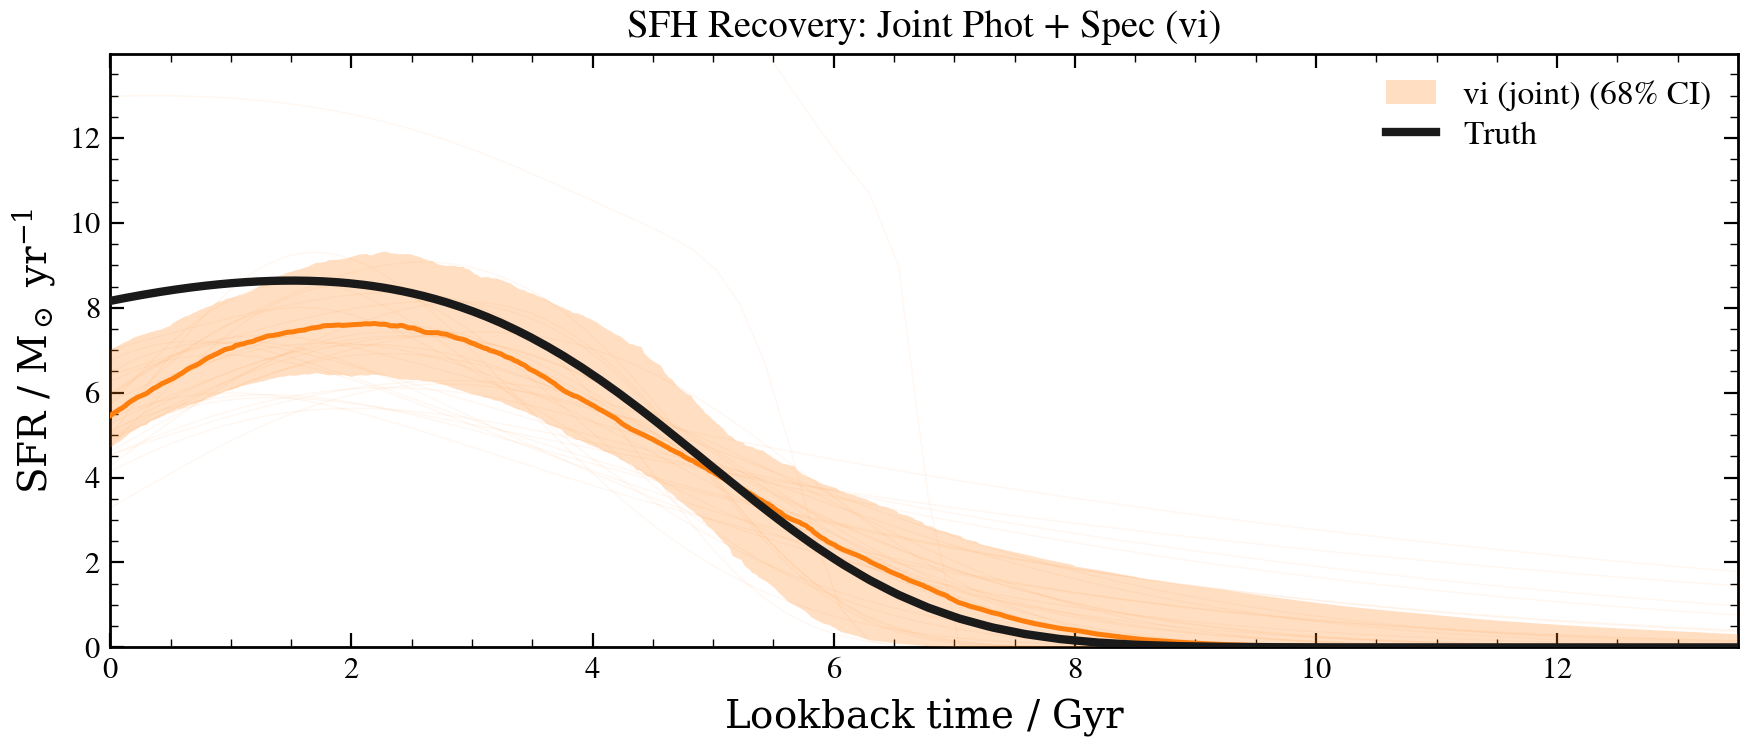

In [11]:
# --- SFH recovery from joint posterior ---
fig, ax = plt.subplots(figsize=(9, 4))
plot_sfh(
    model,
    result_geovi,
    true_params=true_params,
    ax=ax,
    color=COLORS["vi"],
    label="vi (joint)",
    method="geoVI",
)
ax.set_title("SFH Recovery: Joint Phot + Spec (vi)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig11_sfh_joint.png"), dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Laplace-vs-geoVI corner removed (Laplace fit disabled above to keep memory
# bounded). truths_dict is defined here for use in the Phot/Spec/Joint corner.
truths_dict = {p: float(true_params[p]) for p in spec.free_params}

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


OPTIMIZE_KL: Starting 0001


SL: Iteration 0 ⛰:+5.8988e+02 Δ⛰:inf ➽:1.0000e-04


SL: Iteration 0 ⛰:+1.5912e+03 Δ⛰:inf ➽:1.0000e-04


...

MCG: Iteration 6 ⛰:-1.1424e-04 Δ⛰:8.9268e-06 ➽:4.5062e-03 |∇|:1.5562e+00 ➽:5.8521e+00


M: →:1.0 ↺:False #∇²:18 |↘|:2.198434e-03 🞋:8.000000e-05
M: Iteration 3 ⛰:+6.859770e+02 Δ⛰:1.196489e-04 🞋:1.000000e-03


OPTIMIZE_KL: Iteration 0008 ⛰:+6.8598e+02
OPTIMIZE_KL: #(Nonlinear sampling steps) (2, 3, 3, 3, 3, 3, 3, 3)
OPTIMIZE_KL: #(KL minimization steps) 3
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     6.8±    0.07, avg:    +0.19±    0.12, #dof:    200'

OPTIMIZE_KL: Prior residual(s):
dust_tau_bc             :: 'reduced χ²:   0.026±   0.037, avg:   +0.045±    0.15, #dof:      1'
dust_tau_diff           :: 'reduced χ²:    0.47±    0.34, avg:    -0.63±    0.27, #dof:      1'
met_logzsol             :: 'reduced χ²:     0.2±   0.094, avg:    +0.43±    0.11, #dof:      1'
sfh_tsnorm_log_peak_sfr :: 'reduced χ²:    0.18±   0.064, avg:    +0.42±   0.075, #dof:      1'
sfh_tsnorm_peak_lbt_gyr :: 'reduced χ²:     0.5±     0.5, avg:    -0.51±    0.49, #dof:      1'
sfh_tsnorm_skew         :: 'reduced χ²:   0.031±   0.024, avg:    +0.15±   0.085, #dof:      1'
sfh_tsnorm_trunc        :: 'reduced χ²:     2.6±     2.4, avg:     -1.4±    0.83, #dof:      1'
sfh_tsnorm_width_gyr    :: 'reduced χ²:  

Corner plot skipped for Spec-only


Corner plot skipped for Joint


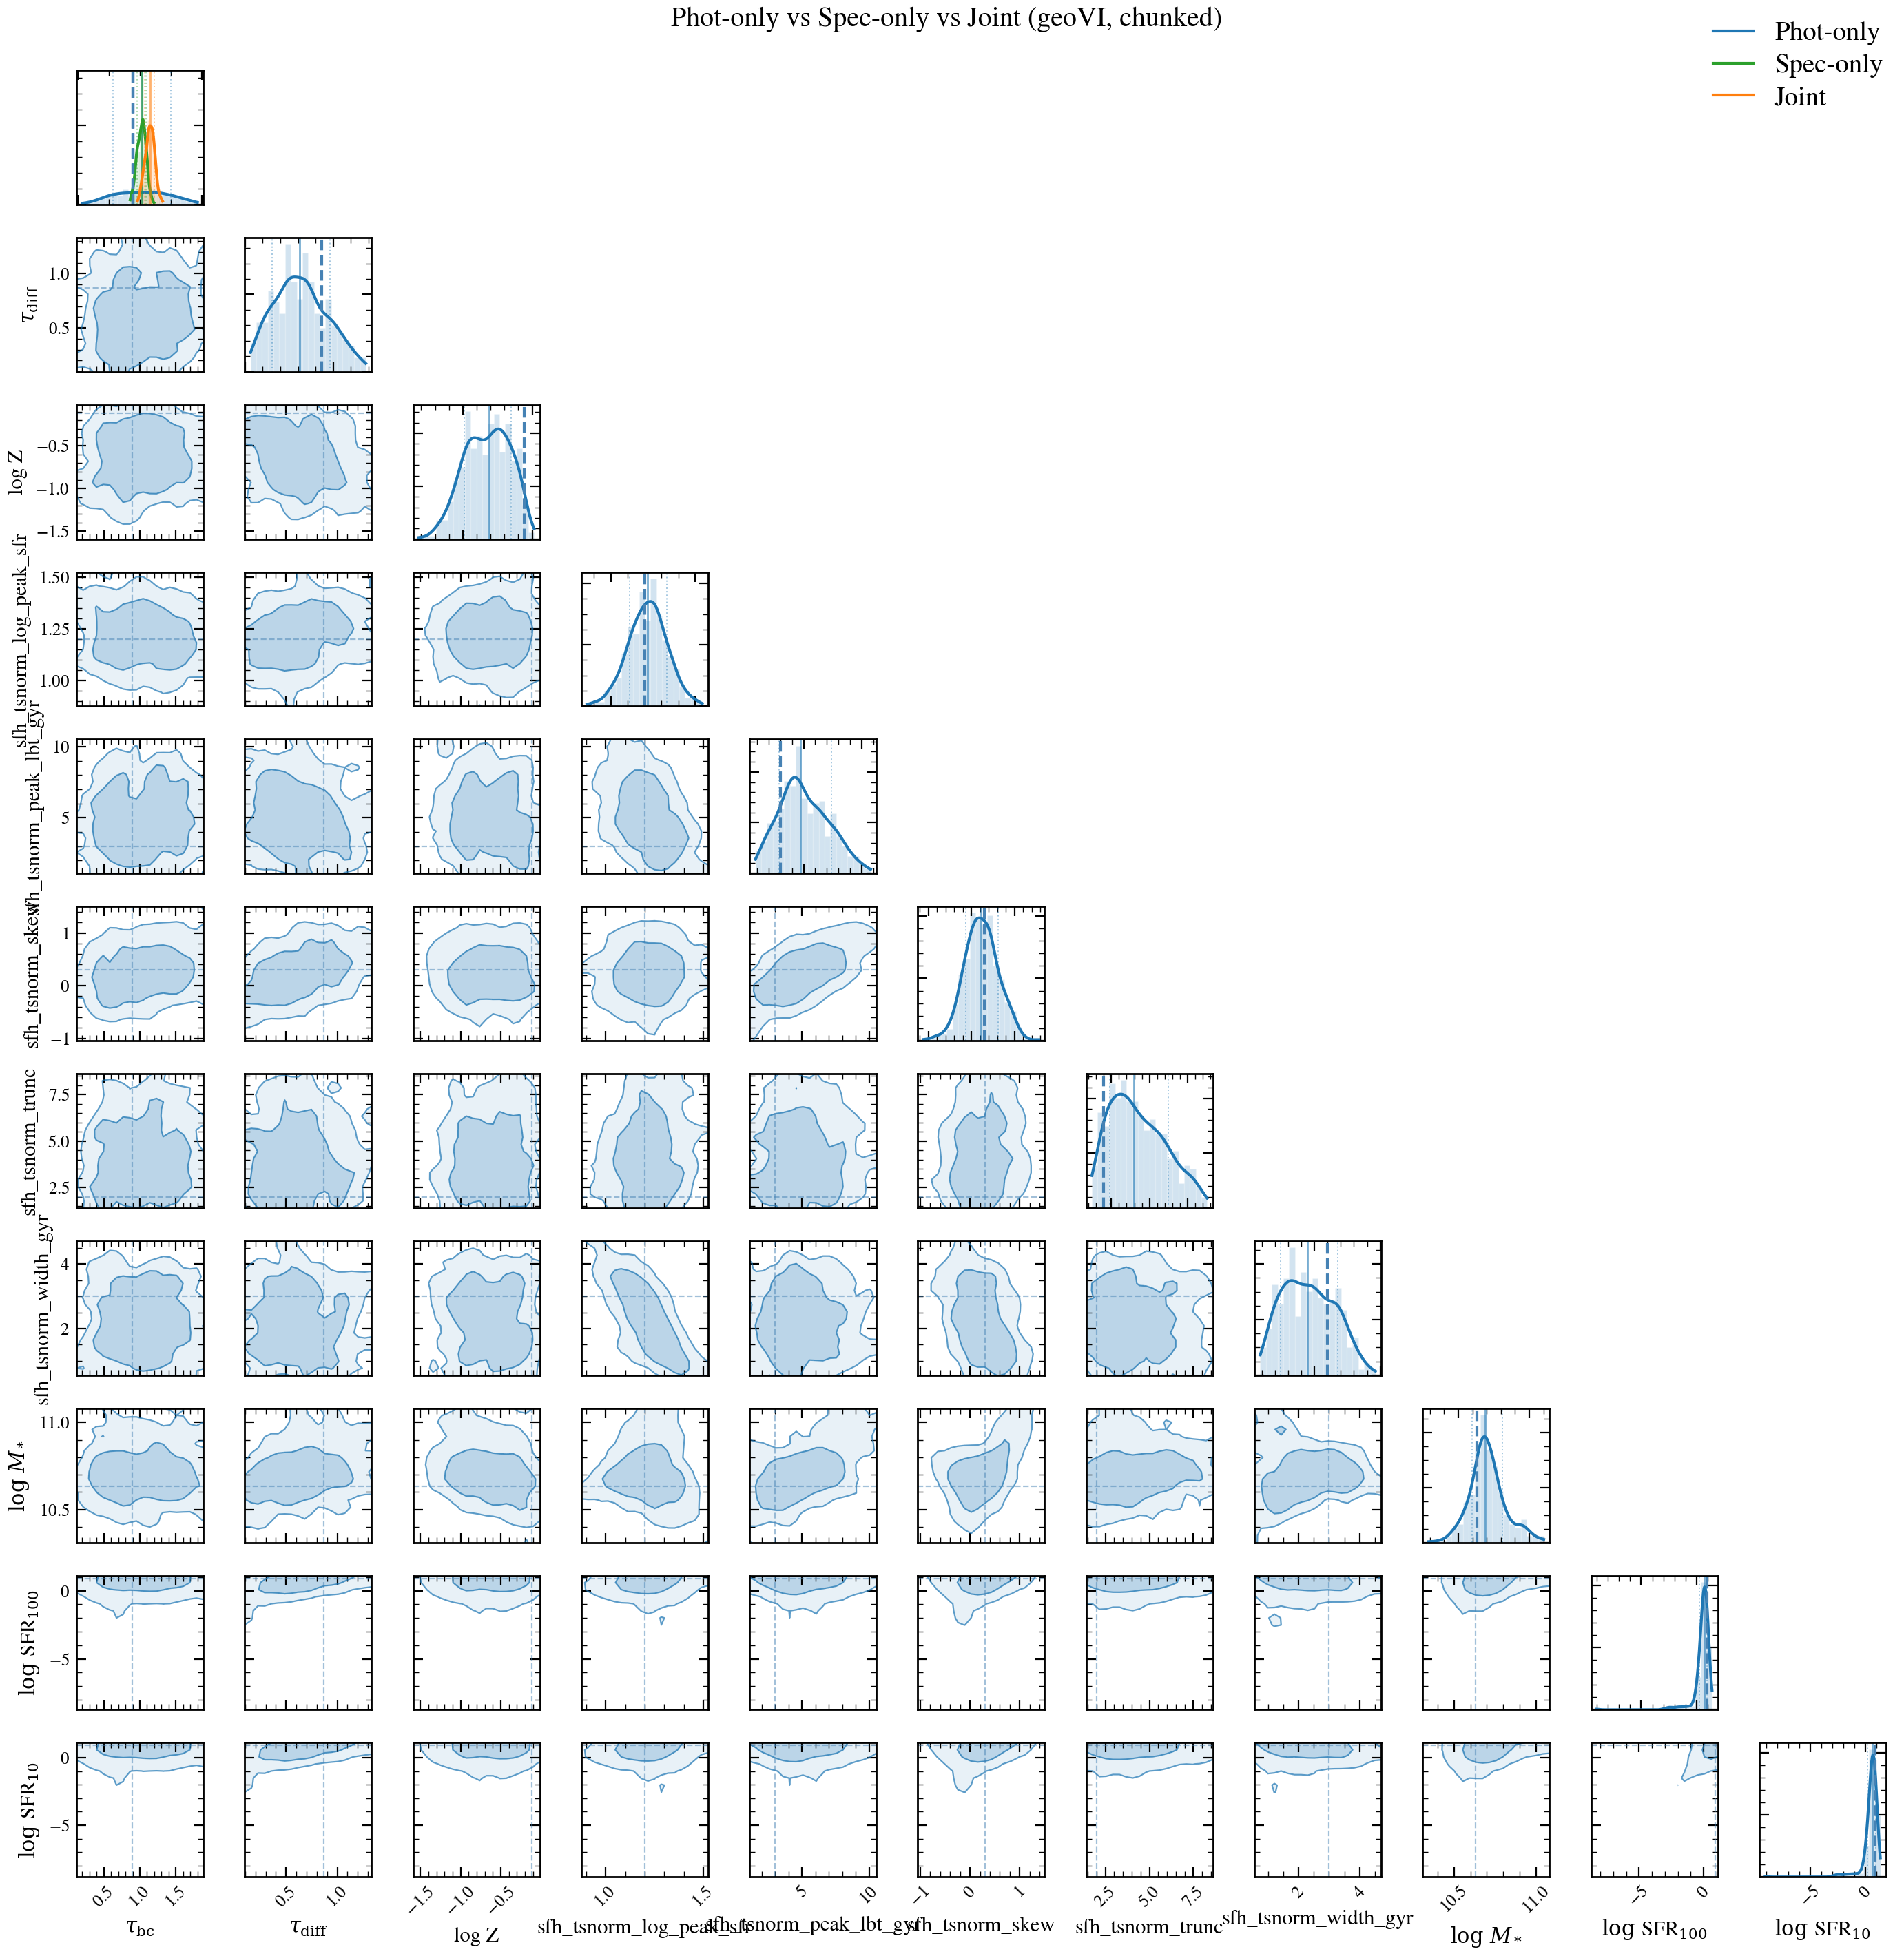

In [13]:
# --- Corner: Phot-only vs Spec-only vs Joint (geoVI with chunked draws) ---
k_phot, k_spec = jax.random.split(jax.random.PRNGKey(77), 2)

result_geovi_phot = fitter_phot.run(
    "vi",
    key=k_phot,
    n_iterations=8,
    n_samples=4,
    n_posterior_samples=400,
    posterior_chunk_size=64,
    verbose=False,
)
_gc.collect()

result_geovi_spec = fitter_spec.run(
    "vi",
    key=k_spec,
    n_iterations=8,
    n_samples=4,
    n_posterior_samples=400,
    posterior_chunk_size=64,
    verbose=False,
)
_gc.collect()

fig = plot_corner_comparison(
    [result_geovi_phot, result_geovi_spec, result_geovi],
    labels=["Phot-only", "Spec-only", "Joint"],
    colors=[COLORS["rt"], COLORS["mcmc_nuts"], COLORS["vi"]],
    truths=truths_dict,
)
if fig is not None:
    fig.suptitle("Phot-only vs Spec-only vs Joint (geoVI, chunked)", y=1.02)
    plt.savefig(
        os.path.join(FIGDIR, "fig11_corner_data_comparison.png"),
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

In [14]:
# Convergence diagnostics
convergence_table(
    {
        "geoVI (joint)": result_geovi,
        "geoVI (phot-only)": result_geovi_phot,
        "geoVI (spec-only)": result_geovi_spec,
    }
)

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
geoVI (joint)        163      193      2.5        —        —       WARN
geoVI (phot-only)      195      230      2.1        —        —       WARN
geoVI (spec-only)      165      224      2.5        —        —       WARN

Warnings:
  [geoVI (joint)] Median ESS = 193 < 400 target — consider more samples
  [geoVI (phot-only)] Median ESS = 230 < 400 target — consider more samples
  [geoVI (spec-only)] Median ESS = 224 < 400 target — consider more samples


{'geoVI (joint)': {'ess_min': 162.96950933350507,
  'ess_median': 192.88174193706098,
  'n_params_low_ess': 0,
  'tau_max_max': 2.5035357943249257,
  'tau_max_median': 2.125003747678462,
  'n_params_short_chain': 0,
  'converged': False,
  'warnings': ['Median ESS = 193 < 400 target — consider more samples']},
 'geoVI (phot-only)': {'ess_min': 195.13116967112006,
  'ess_median': 229.6964237289124,
  'n_params_low_ess': 0,
  'tau_max_max': 2.0909012162826444,
  'tau_max_median': 1.7764081387620967,
  'n_params_short_chain': 0,
  'converged': False,
  'warnings': ['Median ESS = 230 < 400 target — consider more samples']},
 'geoVI (spec-only)': {'ess_min': 165.1793601097271,
  'ess_median': 223.53153369041428,
  'n_params_low_ess': 0,
  'tau_max_max': 2.4700422602979537,
  'tau_max_median': 1.8266562540430007,
  'n_params_short_chain': 0,
  'converged': False,
  'warnings': ['Median ESS = 224 < 400 target — consider more samples']}}

## The pack_data / unpack_prediction Interface

The `Observation` object manages the canonical data ordering:
photometry first, then spectroscopy. Two methods handle all
concatenation and slicing.

- **`pack_data(phot=, spec=)`** validates shapes and concatenates
  into a single vector for the `Fitter`.
- **`unpack_prediction(predicted)`** splits a model prediction back
  into labeled `{"photometry": ..., "spectroscopy": ...}` arrays.

You never need to manually track index boundaries.

In [15]:
# Demonstrate pack / unpack round-trip
packed = obs.pack_data(phot=mock_phot.flux_true, spec=mock_spec.flux_true)
print(f"Packed shape: {packed.shape}  (={obs.n_data_phot} + {obs.n_data_spec})")

components = obs.unpack_prediction(packed)
print(f"Unpacked keys: {list(components.keys())}")
print(f"  photometry shape:   {components['photometry'].shape}")
print(f"  spectroscopy shape: {components['spectroscopy'].shape}")

# Verify round-trip fidelity
assert jnp.allclose(components["photometry"], mock_phot.flux_true)
assert jnp.allclose(components["spectroscopy"], mock_spec.flux_true)
print("Round-trip check passed.")

Packed shape: (205,)  (=5 + 200)
Unpacked keys: ['photometry', 'spectroscopy']
  photometry shape:   (5,)
  spectroscopy shape: (200,)
Round-trip check passed.


## When to Use Joint Fitting

| Scenario | Recommended mode | Why |
|----------|-----------------|-----|
| Only broadband photometry available | Photometry-only | Fastest; constrains mass, dust, SFR |
| Medium-resolution spectrum available | Spectroscopy-only | Breaks age-metallicity degeneracy |
| Both photometry and spectroscopy | **Joint** | Best of both: broadband shape + spectral features |
| Many galaxies, heterogeneous data | Joint where available | `Observation` per galaxy; `fit_batch` handles mixed types |

Joint fitting is especially valuable when:
- The spectrum covers only part of the SED (e.g. optical only, missing UV/NIR)
- Dust parameters are poorly constrained by spectroscopy alone
- You need precise stellar masses alongside detailed SFH recovery